**Objective**:
Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset.


**ARIMA** (Autoregressive Integrated Moving Average) model, used for forecasting time series data. It combines three components: autoregression (AR), differencing (I) and moving averages (MA).
ARIMA is popular because it effectively models time series data by capturing both the autoregressive (AR) and moving average (MA) components, while also addressing non-stationarity through differencing (I).
By using ARIMA, we can analyze and forecast time series data in a sophisticated manner accounting for the patterns, trends, and seasonality.
ARIMA models especially flexible, which is why they are used across very different industries, like finance and weather prediction.
Thus facilitates a 360-degree view of the underlying dynamics for making informed decisions.

Exponential smoothing and ARIMA models are the two most widely used approaches to time series forecasting, and provide complementary approaches to the problem. While exponential smoothing models are based on a description of the trend and seasonality in the data, ARIMA models aim to describe the autocorrelations in the data.



In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import plotly.graph_objects as gr

import warnings
warnings.filterwarnings('ignore')

**Loading the Dataset**


In [70]:
from google.colab import files
uploaded = files.upload()

Saving exchange_rate.csv to exchange_rate (2).csv


In [71]:
df = pd.read_csv('exchange_rate.csv')

df.index = pd.to_datetime(df["date"], format='mixed', dayfirst=True) #Date column is set as the index for the exchange rates


df.head()


,date,Ex_rate
date,,
1990-01-01,1/1/1990 0:00,0.7855
1990-01-02,2/1/1990 0:00,0.7818
1990-01-03,3/1/1990 0:00,0.7867
1990-01-04,4/1/1990 0:00,0.7860
1990-01-05,5/1/1990 0:00,0.7849


In [72]:
df.isnull().sum() #No null values found in the data set

,0
date,0
Ex_rate,0


In [73]:
df.dtypes

,0
date,object
Ex_rate,float64


In [74]:
df["date"] = pd.to_datetime(df["date"], format='mixed', dayfirst=True)  #converting to the datetime format

df["date"].dt.year

df["date"]


,date
date,
1990-01-01,1990-01-01
1990-01-02,1990-01-02
1990-01-03,1990-01-03
1990-01-04,1990-01-04
1990-01-05,1990-01-05
...,...
2010-10-06,2010-10-06
2010-10-07,2010-10-07
2010-10-08,2010-10-08


In [75]:
df.describe()

,date,Ex_rate
count,7588,7588.000000
mean,2000-05-21 12:00:00,0.776974
min,1990-01-01 00:00:00,0.483297
25%,1995-03-12 18:00:00,0.701422
50%,2000-05-21 12:00:00,0.761377
75%,2005-07-31 06:00:00,0.873477
max,2010-10-10 00:00:00,1.102536
std,NaN,0.136620


In [76]:
# Create a figure
fig = gr.Figure()

# Add a trace for USD to Australian Dollar exchange rate
fig.add_trace(gr.Scatter(x=df['date'], y=df['Ex_rate'], mode='lines', name='USD to AUD', line=dict(color='blue')))

# Update layout
fig.update_layout(title='USD to AUD Exchange Rate Over Time',
                   xaxis_title='Date',
                   yaxis_title='Exchange Rate')

# Show plot
fig.show()

There are no missing values in either of the columns and has 7588 records.

The 'date' column is converted to type datetime64, and contains datetime values.
The 'Ex_rate' column is of type float64 and contains numerical values of exchange rates.

The exchange rates range from a minimum of 0.483297 to a maximum of 1.102536, with a mean of approximately 0.776974 and a standard deviation of approximately 0.136620.

Hence, the overview of the dataset structure and statistics of the exchange rate data.

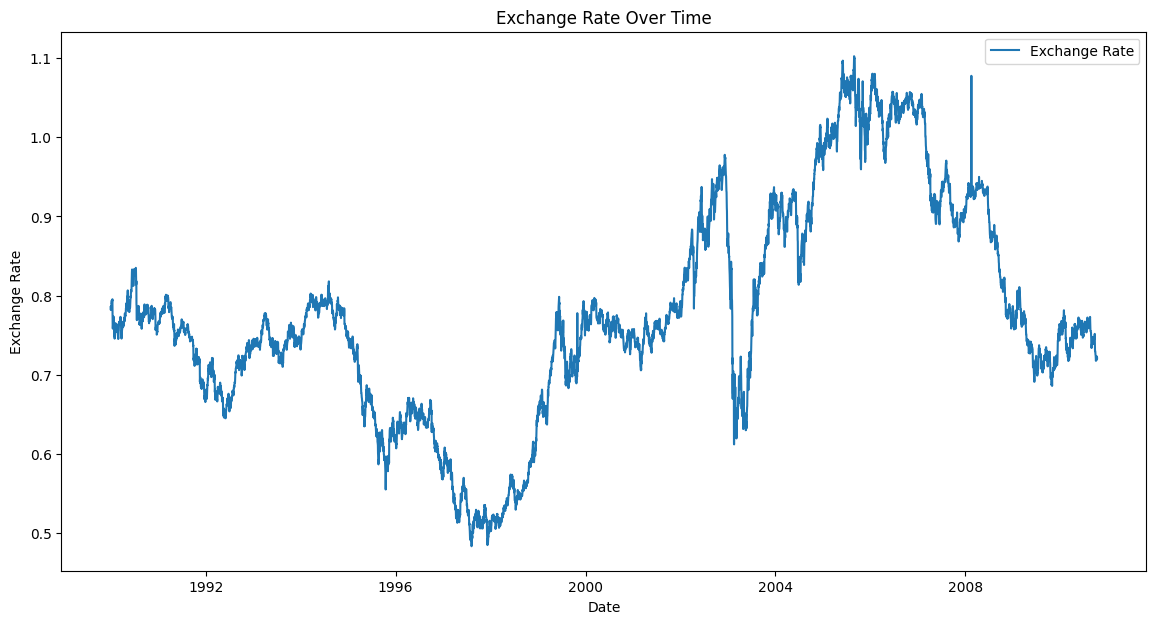

In [77]:
# Plotting the Original Exchange Rate
plt.figure(figsize=(14, 7))
plt.plot(df["date"], df["Ex_rate"], label='Exchange Rate')
plt.title('Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

We can break down our exchange rate time series into its trend, seasonality, and residual components. We’ll be using the seasonal_decompose model from the statsmodels library.

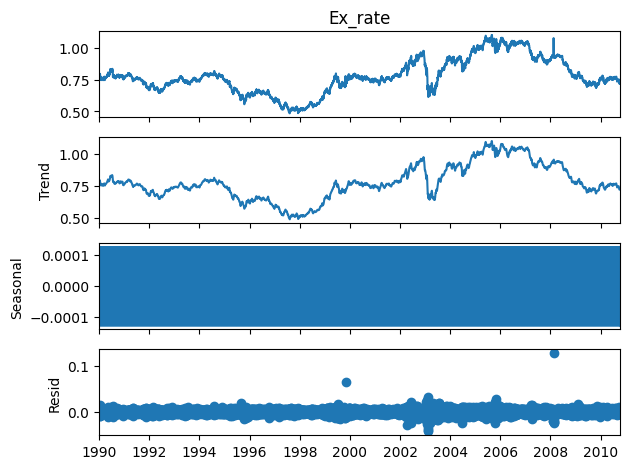

In [78]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Ex_rate'], model='additive')

decomposition.plot()

plt.show()

To further understand the underlying structure of the exchange rate time series, we performed a decomposition on the log-transformed data. The results highlight the following key insights:

**Trend Component**: The series exhibits long-term fluctuations, confirming the there is fluctuating trend.

**Seasonal Component**: The seasonality is negligible.

**Residual Component**: While mostly centered around zero, there are noticeable spikes, suggesting periods of increased volatility.

This decomposition confirms that the exchange rate movement is primarily driven by fluctuating trend, with no significant seasonal pattern. We will proceed with evaluating the residual diagnostics of our ARIMA model to ensure it effectively captures the randomness in the data.


**Stationarity Check (ADF Test)**

We will check if the time series is stationary using the Augmented Dickey-Fuller (ADF) test. We use the adfuller() method to perform the ADF test, which provides the ADF statistic and p-value.

dropna(): Removes the missing values created after differencing.
If the p-value is greater than 0.05, the series is non-stationary and differencing is needed.

In [79]:
exch_rate = df['Ex_rate'].dropna()
result_org = adfuller(exch_rate)
print('ADF Statistic: %f' % result_org[0])
print('p-value: %f' % result_org[1])

if result_org[1] < 0.05:
    print("Interpretation: Reject Null Hypothesis -->  The original series is Stationary,no differencing is needed.\n")
else:
    print("Interpretation: Cannot reject Null Hypothesis --> The original series is Non-Stationary.\n") # Apply first-order differencingdata

ADF Statistic: -1.664994
p-value: 0.449233
Interpretation: Cannot reject Null Hypothesis --> The original series is Non-Stationary.



The ADF statistic is not sufficiently negative to reject the null hypothesis.

The p-value is greater than the typical significance level of 0.05, indicating that we cannot reject the null hypothesis - that thr original series is stationary.

Hence, we go with differencing.

**Differencing** for  Stationary Exchange Rates

To achieve stationarity for modeling purposes, we can apply differencing to the time series data. Differencing involves computing the differences between consecutive observations.


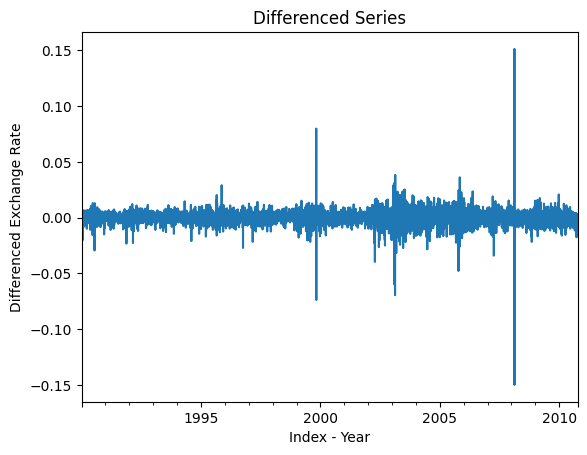

ADF Statistic (differenced): -99.393431
p-value (differenced): 0.000000
Interpretation: The differenced series is Stationary.


In [80]:
# Perform the Augmented Dickey-Fuller test on the differenced series
# exch_rate.diff(): Computes the first-order difference of the exchange rates to remove trends.
exch_rate_diff = exch_rate.diff().dropna() # remove missing values after differencing

exch_rate_diff.plot(title='Differenced Series') #visualise
plt.xlabel('Index - Year')
plt.ylabel('Differenced Exchange Rate')
plt.show()

result_diff = adfuller(exch_rate_diff)
print('ADF Statistic (differenced): %f' % result_diff[0])
print('p-value (differenced): %f' % result_diff[1])

if result_diff[1] < 0.05:
  print("Interpretation: The differenced series is Stationary.")
else:
  print("Interpretation: The differenced series is Non-Stationary.")

From the above results, we can conclude that the differenced time series is stationary. This stationarity is essential for modeling purposes, as many time series models, including ARIMA, require stationary data.

The number of times the data is differenced to achieve stationarity (in this case **d=1)**.


**ACF and PACF** Plotting (Model Order Identification)

We use tools like ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) to determine the values of p, d, and q. The number of lags where ACF cuts off is q, and where PACF cuts off is p. We also have to choose the appropriate value for d by creating a situation where, after differencing, the data resembles white noise. **For our data, we choose 1 for both p and q because we see a significant spike in the first lag for each. 1 for d as 1 level of differencing showed stationarity in data.**

**plot_acf():** Plots the Autocorrelation Function (ACF) to check for the number of MA terms (q).

**plot_pacf():** Plots the Partial Auto correlation Function (PACF) to check for the number of AR terms (p).

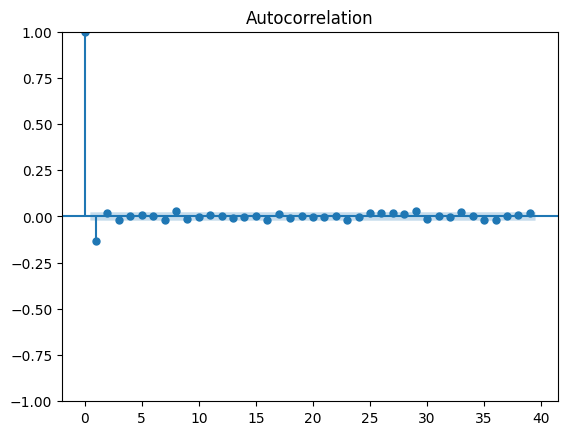

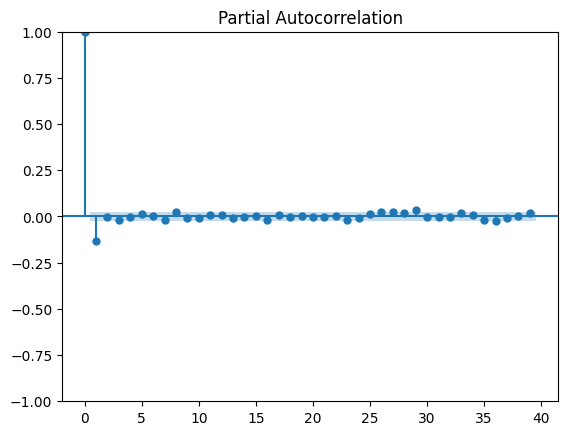

In [81]:
plot_acf(exch_rate_diff)
plt.show()

plot_pacf(exch_rate_diff)
plt.show()



**ARIMA Model Selection**

When we build an ARIMA model, we have to consider the p, d, and q terms that go into our ARIMA model.

**The first parameter, p,** is the number of lagged observations. By considering p, we effectively determine how far back in time we go when trying to predict the current observation. We do this by looking at the autocorrelations of our time series, which are the correlations in our series at previous time lags.

**The second parameter, d,** refers to the order of differencing. Differencing simply means finding the differences between consecutive timesteps. It is a way to make our data stationary, which means removing the trends and any changes in variance over time. d indicates differencing at which order you get a process stationary.

**The third parameter q** refers to the order of the moving average (MA) part of the model. It represents the number of lagged forecast errors included in the model. Unlike a simple moving average, which smooths data, the moving average in ARIMA captures the relationship between an observation and the residual errors from a moving average model applied to lagged observations.



Once the p, d, and q values are chosen from the ACF and PACF plots, the model estimates additional parameters, such as coefficients for the autoregressive and moving average terms, through maximum likelihood estimation (MLE).



In [82]:
# Split data into train and test

train_size = int(len(exch_rate) * 0.7)
train, test = exch_rate.iloc[:train_size], exch_rate.iloc[train_size:]

# Fit ARIMA model

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

**Insample forecasting** - We use the fitted values from our ARIMA(1,1,1) model

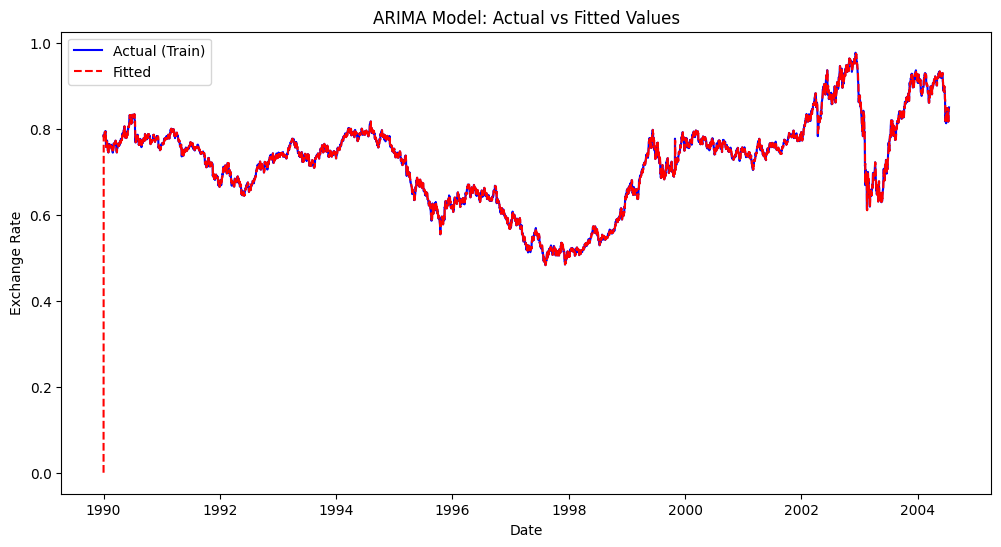

In [83]:
# Actual vs Fitted - ARIMA(1,1,1) model
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Actual (Train)', color='blue')
plt.plot(train.index, model_fit.fittedvalues, label='Fitted', color='red', linestyle='--')
plt.title('ARIMA Model: Actual vs Fitted Values')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

When we set the dynamic=False the in-sample lagged values are used for prediction and the model gets trained up until the previous value to make the next prediction. This can make the fitted forecast and actuals look artificially good.
However to find the best Arima Model is by Out-of-Time cross-validation
forecasting the future and compare the forecast with the actual performance.

**Out-of-Sample** Forecasting (test data)

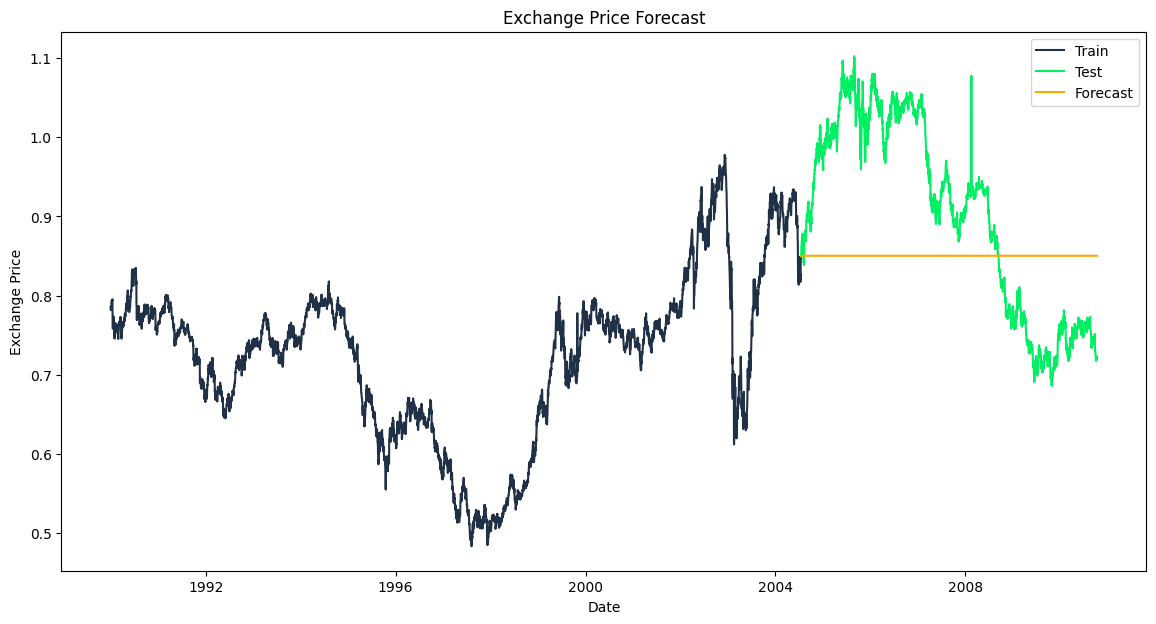

In [99]:
# Forecast
forecast = model_fit.forecast(steps=len(test))
# Plot the results with specified colors
plt.figure(figsize=(14,7))
plt.plot(train.index, train, label='Train', color='#203147')
plt.plot(test.index, test, label='Test', color='#01ef63')
plt.plot(forecast.index, forecast, label='Forecast', color='orange')
plt.title('Exchange Price Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Price')
plt.legend()
plt.show()

From the chart, the ARIMA(1,1,1) model seems to give a directionally correct forecast. And the actual observed values lie within the 95% confidence band.However, the predicted values are not in much of sync with the actual values. The predicted are either lower tha actual or higher than the actual.

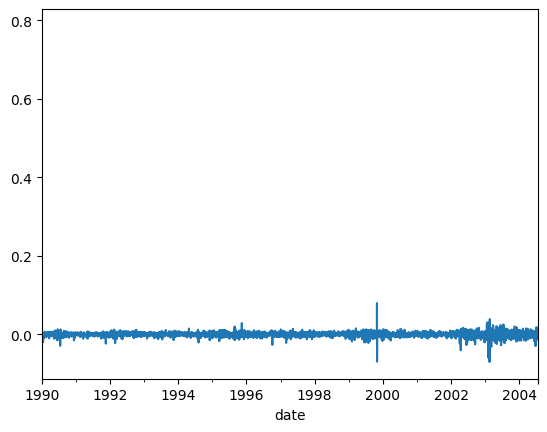

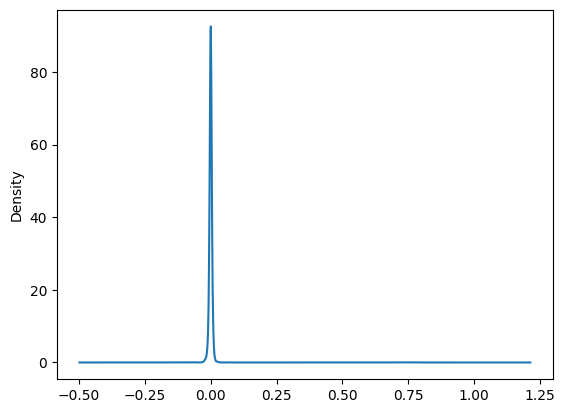

count    5311.000000
mean        0.000161
std         0.012099
min        -0.070170
25%        -0.002361
50%         0.000184
75%         0.002587
max         0.785500
dtype: float64


In [85]:
# line plot of residuals
residuals = model_fit.resid
residuals.plot()
plt.show()
# density plot of residuals
residuals.plot(kind='kde')
plt.show()
# summary stats of residuals
print(residuals.describe())

The distribution of the residual errors is displayed. The results show that indeed there is very slight bias in the prediction (mean is almost zero in the residuals but with a deviation of 0.0121).

Running the below  prints a summary of the fit model. This summarizes the coefficient values used as well as the skill of the fit on the on the in-sample observations.

In [86]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 5311
Model:                 ARIMA(1, 1, 1)   Log Likelihood               20096.009
Date:                Thu, 22 Jan 2026   AIC                         -40186.018
Time:                        17:28:59   BIC                         -40166.286
Sample:                    01-01-1990   HQIC                        -40179.124
                         - 07-16-2004                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3256      0.107     -3.054      0.002      -0.535      -0.117
ma.L1          0.2722      0.107      2.535      0.011       0.062       0.483
sigma2      3.022e-05   1.74e-07    173.781      0.0

**Evaluate model statistics**

AIC/BIC: Use the Akaike Information Criterion (AIC) or Bayesian Information Criterion (BIC) to select the model with the lowest value, indicating the best trade-off between fit and complexity.

Lower the AIC and BIC values mean the model fits better, but we might also compare the results with those from simpler models to avoid overfitting. I'm printing the numbers here but they make the most sense in the context of comparing to other ARIMA models on the same data, in order to find the ARIMA model that works best.


We can also evaluate the mean squared error, to assess the model's fit. This is a practical metric. A lower RMSE indicates a better ARIMA model, reflecting smaller differences between actual and predicted values, and it's on the scale of the data. That is, the RMSE of 0.1322 signifies that, on average, our model's predictions deviate from the actual exchnage rates by about $0.1322.


In [87]:
print(f"AIC: {model_fit.aic}")
print(f"BIC: {model_fit.bic}")

forecast = forecast[:len(test)]
test_rate = test[:len(forecast)]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test_rate, forecast))
print(f"RMSE: {rmse:.4f}")

mae = mean_absolute_error(test_rate, forecast)
print(f"MAE: {mae:.4f}")

mape = mean_absolute_percentage_error(test_rate, forecast)
print(f"MAPE: {mape:.4f}")

print("mse: ",mean_squared_error(test_rate, forecast))
#print(forecast.head())
#print(test_rate.head())

AIC: -40186.01826556593
BIC: -40166.28622422322
RMSE: 0.1322
MAE: 0.1191
MAPE: 0.1300
mse:  0.01747036849093525


The parameters of the ARIMA model are defined as follows:

p: The lag order, representing the number of lag observations incorporated in the model.

d: Degree of differencing, denoting the number of times raw observations undergo differencing.

q: Order of moving average, indicating the size of the moving average window.

The below piece of code iterates for different values of p,d and q and returns the best order based on the lowest AIC value.

In [88]:
import itertools

p = range(0, 4)
d = range(1, 2)
q = range(0, 4)
pdq = list(itertools.product(p, d, q)) #Generates all combinations of p, d and q for the grid search.


best_aic = np.inf
best_order = None
best_model = None

for order in pdq:
    try:
        model = ARIMA(train, order=order)
        results = model.fit() #Fits the ARIMA model for each combination of p, d and q.

        if results.aic < best_aic: #Evaluates the model using the Akaike Information Criterion (AIC), where a lower AIC indicates a better model.
            best_aic = results.aic
            best_order = order
            best_model = results
    except:
        continue

print(f'Best ARIMA order: {best_order} with AIC: {best_aic}')

Best ARIMA order: (3, 1, 2) with AIC: -40195.99638164553


**Model Fitting and Forecasting**

Fit the ARIMA model with the best parameters identified earlier and then generate forecasts for future values.

**ARIMA():** Initializes the ARIMA model with the best parameters (p, d, q).

**fit():** Fits the ARIMA model to the time series data and estimates the model's parameters.

**forecast():** Forecast Exchange Rates for the specified number of future periods.

**steps:** The number of periods into the future for which the forecast is needed.



In [89]:
# Fit ARIMA model for best parameters from Grid Search

final_model = ARIMA(train, order= best_order)

final_results = final_model.fit()



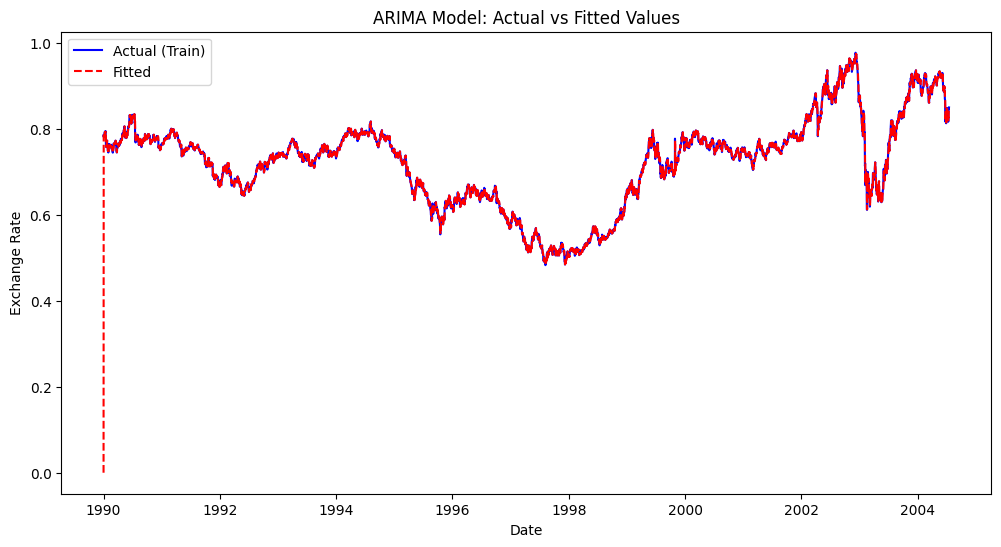

In [90]:
# Actual vs Fitted
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Actual (Train)', color='blue')
plt.plot(train.index, final_results.fittedvalues, label='Fitted', color='red', linestyle='--')
plt.title('ARIMA Model: Actual vs Fitted Values')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

In [91]:
forecast_rates = final_results.forecast(steps=len(test))

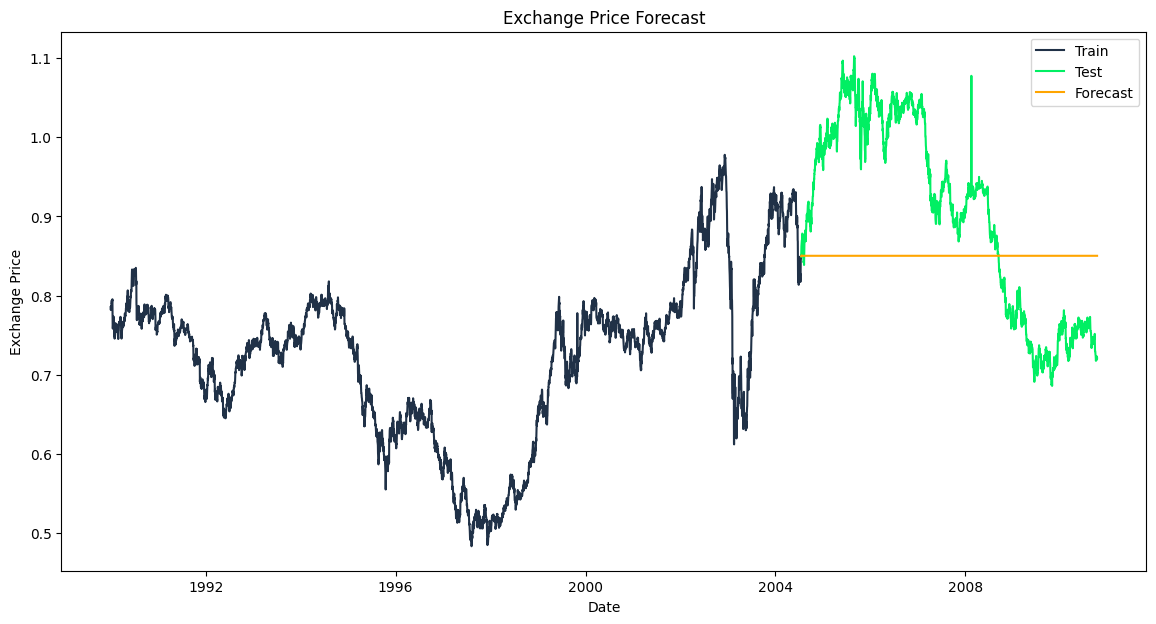

In [100]:
# Plot the results with specified colors
plt.figure(figsize=(14,7))
plt.plot(train.index, train, label='Train', color='#203147')
plt.plot(test.index, test, label='Test', color='#01ef63')
plt.plot(forecast_rates.index, forecast_rates, label='Forecast', color='orange')
plt.title('Exchange Price Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Price')
plt.legend()
plt.show()

**Model Evaluation**:

Plotting the  values of the original time series data along with the forecasted values to visually assess the model's performance.



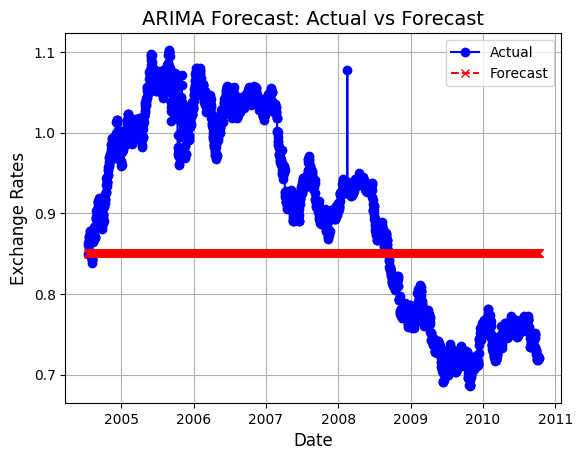

In [93]:
plt.plot(test.index, test, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(forecast_rates.index, forecast_rates, label='Forecast', color='red', linestyle='--', marker='x')

plt.title('ARIMA Forecast: Actual vs Forecast', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Exchange Rates', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

Lower the AIC and BIC values mean the model fits better, but we might also compare the results with those from simpler models to avoid overfitting. I'm printing the numbers here but they make the most sense in the context of comparing to other ARIMA models on the same data, in order to find the ARIMA model that works best.


A lower RMSE indicates a better ARIMA model, reflecting smaller differences between actual and predicted values, and it's on the scale of the data. The Arima Model fitted with the best parameters gave RMSE value of 0.1689. The second model doesnot work better than the first one which was fitted with parameters based on the ACF and PACF plots.

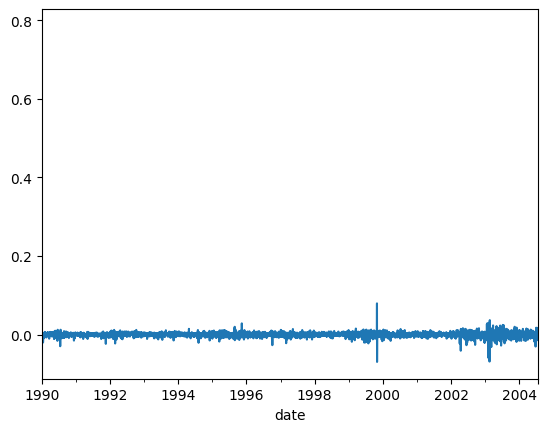

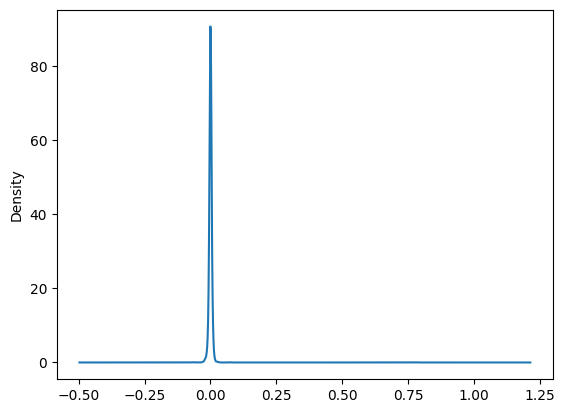

count    5311.000000
mean        0.000161
std         0.012096
min        -0.069397
25%        -0.002314
50%         0.000188
75%         0.002574
max         0.785500
dtype: float64


In [94]:
# line plot of residuals
residuals_best = final_results.resid
residuals_best.plot()
plt.show()
# density plot of residuals
residuals_best.plot(kind='kde')
plt.show()
# summary stats of residuals
print(residuals_best.describe())

The residual errors seem fine with near zero mean and uniform variance.

In [95]:
print(final_results.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 5311
Model:                 ARIMA(3, 1, 2)   Log Likelihood               20103.998
Date:                Thu, 22 Jan 2026   AIC                         -40195.996
Time:                        17:29:32   BIC                         -40156.532
Sample:                    01-01-1990   HQIC                        -40182.207
                         - 07-16-2004                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3786      0.117     -3.248      0.001      -0.607      -0.150
ar.L2         -0.6352      0.130     -4.874      0.000      -0.891      -0.380
ar.L3         -0.0679      0.008     -8.484      0.0

The model summary provides lot of information. The table above is the coefficients table where the values under ‘coef’ are the weights of the respective terms.

The P-Value in P>|z|column is less than 0.05 making the respective X to be significant.


In [96]:
print(f"AIC: {final_results.aic}")
print(f"BIC: {final_results.bic} \n")

forecast_rates = forecast_rates[:len(test)]
fin_test_rate = test[:len(forecast_rates)]


# Calculate RMSE
rmse1 = np.sqrt(mean_squared_error(fin_test_rate, forecast_rates))
print(f"RMSE: {rmse1:.4f}")

mae1 = mean_absolute_error(fin_test_rate, forecast_rates)
print(f"MAE: {mae1:.4f}")

mape1 = mean_absolute_percentage_error(fin_test_rate, forecast_rates)
print(f"MAPE: {mape1:.4f}\n")

print("mse :", mean_squared_error(fin_test_rate, forecast_rates))

#print(forecast_rates.head())
#print(fin_test_rate.head())

AIC: -40195.99638164553
BIC: -40156.53229896011 

RMSE: 0.1322
MAE: 0.1191
MAPE: 0.1300

mse : 0.01747406150850846


The below performance parameter values of the ARIMA with pdq as 1,1,1 and with pdq set to best parameter values 3,1,2 are almost the same as compared to the above output, with a slightly lower value variation in the AIC value of the ARIMA model with pdq 3,1,2(better model).

AIC: -40186.01826556593
BIC: -40166.28622422322
RMSE: 0.1322
MAE: 0.1191
MAPE: 0.1300

However, in both the models the MAPE value ( Mean Absolute Percentage Error) shows 13% MAPE implies the model is about 87% accurate in predicting the test  observations.

**Conclusion**:
The ARIMA(1,1,1) model or ARIMA(3,1,2) has performed the same in capturing long-term trends in the exchange rate data. However, it tends to smooth out short-term fluctuations and does not fully account for volatility clustering observed in the residual analysis.

For more robust forecasting, other models such as ARIMA-GARCH (to handle volatility), LSTMs (for capturing complex patterns), or XGBoost (for non-linear dependencies) could be considered.

However, for the scope of this assignment, we will continue our analysis by exploring Exponential Smoothing as an alternative forecasting approach.



**Types of Exponential Smoothing Models**

The choice of the Exponential Smoothing model depends on the characteristics of the time series:

**Simple Exponential Smoothing** (SES), Suitable for data with no trend or seasonality. It applies a smoothing factor to adjust forecasts based on past values.
**Holt's Linear Trend Model**, Suitable for data with a linear trend but no seasonality. It introduces an additional parameter,to capture trends over time.

**Holt-Winters (Additive or Multiplicative)** ,  Suitable for data with both trend and seasonality. It incorporates seasonal smoothing along with level and trend components.

Given Dataset:

There is a clear long-term trend, but no strong seasonal component.
Given this, Holt's Linear Trend Model would be the most appropriate choice, as it accounts for long-term trends while avoiding unnecessary seasonal adjustments.

Best Alpha: 0.9, Best Beta: 0.01, Best RMSE: 0.005514168461143229
AIC: -54013.64755783967


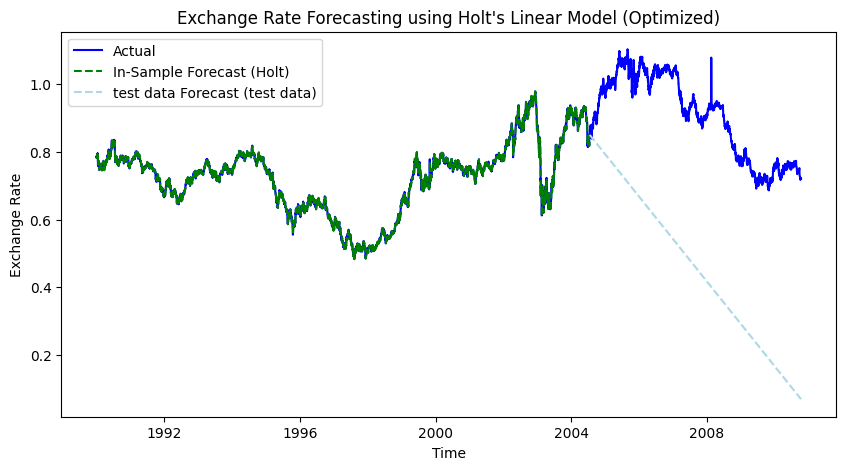

In [97]:
from statsmodels.tsa.holtwinters import Holt
from itertools import product

# Define grid search range for smoothing parameters
alpha_values = np.arange(0.1, 1.0, 0.1)  # Level smoothing
beta_values = np.arange(0.01, 0.5, 0.05)  # Trend smoothing


best_alpha, best_beta, best_rmse = None, None, float("inf")

# Perform grid search
for alpha, beta in product(alpha_values, beta_values):
    model = Holt(train, initialization_method="estimated")
    fitted_model = model.fit(smoothing_level=alpha, smoothing_slope=beta)

    # Get in-sample fitted values
    predictions = fitted_model.fittedvalues

    # Calculate RMSE
    hlt_rmse = np.sqrt(mean_squared_error(train, predictions))

    # Update best parameters if RMSE improves
    if hlt_rmse < best_rmse:
        best_alpha, best_beta, best_rmse = alpha, beta, hlt_rmse

print(f"Best Alpha: {best_alpha}, Best Beta: {best_beta}, Best RMSE: {best_rmse}")
print(f"AIC:" ,fitted_model.aic)
# Fit final model using best parameters
best_model = Holt(train, initialization_method="estimated").fit(
    smoothing_level=best_alpha, smoothing_slope=best_beta
)


# Generate in-sample predictions
in_sample_preds = best_model.fittedvalues

# Generate test data/out of sample forecast ()
future_steps = len(test)
holt_forecast = best_model.forecast(steps=len(test))


# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(exch_rate, label="Actual", color="blue")
plt.plot(in_sample_preds, label="In-Sample Forecast (Holt)", linestyle="dashed", color="green")
plt.plot(test.index, holt_forecast,
         label="test data Forecast (test data)", linestyle="dashed", color="lightblue")
plt.legend()
plt.title("Exchange Rate Forecasting using Holt's Linear Model (Optimized)")
plt.xlabel("Time")
plt.ylabel("Exchange Rate")
plt.show()

In [98]:
# ---- Holt's Linear Model Evaluation ----
holt_rmse = np.sqrt(mean_squared_error(test, holt_forecast))
holt_mae = mean_absolute_error(test, holt_forecast)
holt_mape = mean_absolute_percentage_error(test, holt_forecast)

# Print results
print(f"Holt’s Linear Model - RMSE: {holt_rmse}, MAE: {holt_mae}, MAPE: {holt_mape}")

print(f"ARIMA(1,1,1) Model - RMSE: {rmse}, MAE: {mae}, MAPE: {mape}")

print(f"ARIMA(3,1,2) OPTIMISED Model - RMSE: {rmse1}, MAE: {mae1}, MAPE: {mape1}")

Holt’s Linear Model - RMSE: 0.4647356711172191, MAE: 0.44330598001216914, MAPE: 0.5114777835083603
ARIMA(1,1,1) Model - RMSE: 0.13217552152700307, MAE: 0.11905171859795068, MAPE: 0.12997253717457835
ARIMA(3,1,2) OPTIMISED Model - RMSE: 0.13218949091553556, MAE: 0.11906293690769902, MAPE: 0.12998036846289265


**Final Conclusion:**

**Holt's Linear Model (α = 0.9, β = 0.01)**

**Performance**: Low RMSE (0.4647356711172191) and MAE (0.44330598001216914), indicating accuracy levels lower compared to the ARIMA models. MAPE 0.51 indicating 59% accurate data prediction .

**Advantages**:
Simple and computationally efficient.
Effectively captures linear trends.
Provides stable forecasts.

**Limitations**:
Assumes a continuous linear (downward) trend, which may not hold for real-world exchange rates and cannot model seasonality or complex patterns.
Assumes a persistent downward  trend, which is unrealistic.

**ARIMA(1,1,1) and (3,1,2)** Models :

**Performance**: Lower RMSE (0.1322) and MAE (0.1191) compared to Holt's model, suggesting better accuracy. However, it had a very low AIC (-40185 and -40195), meaning it fits the training data well in terms of complexity and likelihood.
MAPE 0.13 indicating 87% data accuracy in prediction.

**Advantages**:
Captures past dependencies and autocorrelations.
Suitable for non-stationary data due to differencing.

**Limitations**:
Does not generalize well to future trends in this dataset.
Assumes the stable linear trend over different periods , which is again unrealistic.

The USD/AUD exchange rate has exhibited non-stationary behavior with long-term fluctuations rather than a strictly increasing or decreasing trend.

Neither of the two models (Holt's Linear or ARIMA) fully captured the complexity of exchange rate movements, as both assumed a persistent stable or downward trend in future forecasts respectively, contradicting the historical trends that include reversals and volatility.
Holt's Linear Model was less accurate compared to ARIMA, but neither model is ideal for long-term forecasting.

While this analysis was compare the ARIMA and Exponential Smoothing techniques, more advanced Hybrid Models to overcome ARIMA's weakness in capturing non-linear patterns can be done by combining it with models like Support Vector Regression (SVR) or Long Short-Term Memory (LSTM) networks to improve accuracy by leveraging both linear (ARIMA) and non-linear (deep learning) strengths, especially for highly volatile currencies.
